# The matter-wave microscope

In this tutorial, we are going to demonstrate the working principles behind the [matter-wave microscope](https://www.nature.com/articles/s41586-021-04011-2), and see how it can be used to magnify the density profile of atomic Bose-Einstein condensates (BECs). To perform such a simulation, we are going to show how to use the specialized GPE solver implemented in the `rSSFM` class, along the it's dedicated `AnalyticPotential` class. 

## Introduction

One of the challenges arising when studying BECs in optical lattices is the diffraction limit: Most optical lattices have very short lattice spacing, requiring extremely high numerical apertures to be properly imaged. These high apertures are usually not even sufficient in the case of arrays of cylindrical BECs, as the depth of view is limited. One method to overcome these limitations is the matter-wave microscope.

The matterwave microscope uses harmonic traps to realise transformation of the atomic wavefunctions equivalent to the effect of lenses on electromagnetic fields. This can be understood readily by noticing that a quarter-period evolution in a harmonic trap of angular frequency $\omega$ as the same effect on the wavefunction $\psi (t = 0)$ that of a Fourier transform.

Let's demonstrate this with some simple simulations. We are going to simulate the evolution of a gaussian wavepacket with various parameters and see what happens over a quarter-period in an harmonic trap.


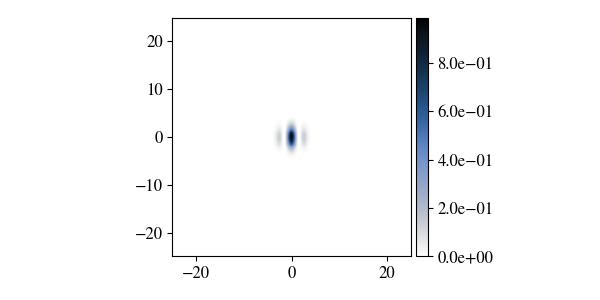

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import Potential, create_parameter
from bloch_schrodinger.plotting import plot_eigenvector
from BECs.ssfm import SSFM
from BECs.potentialT import PotentialT
from BECs.ufuncs import gaussian2D



%matplotlib widget

### ----------------------
# Setting up the potential

s = 50 # simulation box size
resolution = (256,256) # Simulation box resolution

harmonic_trap = Potential( # For now, we only need a simple Potential object
    unitvecs=[[s, 0], [0, s]], # A square box of side s
    resolution=resolution,
    v0 = 0
)

T = 20 # Period, in arbitrary time unit
omega = 2 * np.pi / T # angular frequency of the trap

harmonic_trap.set( # We set the potential profile
    (harmonic_trap.x**2 + harmonic_trap.y**2) * omega**2 / 2
)

### ----------------------
# Setting up initial wavepacket, with a few parameter dimensions

k = create_parameter("k", np.linspace(1,3, 3)) # Initial wave-vector of the packet
sigma = create_parameter("sigma", np.linspace(2, 4, 2)) # Initial wavepacket width

psi0 = gaussian2D( # The initial wavepacket is a superposition of two gaussian wavepacket with a opposite wavevectors k and -k
    harmonic_trap.x, harmonic_trap.y,
    x0 = 0, y0 = 0,
    sigmax= sigma, sigmay=sigma,
    amp = 1
) * np.cos(harmonic_trap.x * k)

# We can use the plot_eigenvector function to plot the mode profile

plot_eigenvector(
    [[abs(psi0)**2]], [[None]], [['amplitude']]
)
plt.show()

Now we can simulate the time-evolution of this wavepacket. Using the Gross-Pitaevskii equation here, when there is no interactions is very much overkill, but in real systems, the interactions cannot always be suppressed.

In [12]:
g = 0 # Interactions
t_init = 0
t_final = T / 4 # We are going to simulate a quarter period evolution

t_samples = create_parameter('t', np.linspace(t_init, t_final, 50)) # We are going to save 50 time points

foo = SSFM(
    potential = harmonic_trap, psi0 = psi0, g = 0
)

psi = foo.solve(
    t_init, t_final, t_samples, parallelize=True, n_cores=6 # We are going to parallelize on 6 cores, if your machine does not support it, feel free to lower n_cores
)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    2.4s remaining:    2.4s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    2.7s finished


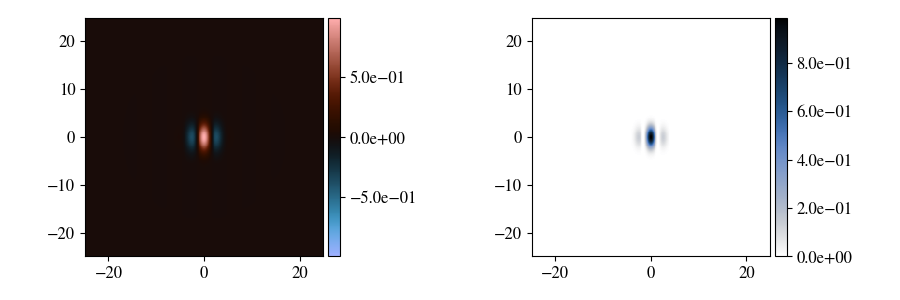

In [13]:
plot_eigenvector(
    [[psi.real, abs(psi)**2]], [[None]*2], [['real', 'amplitude']]
)
plt.show()

We can clearly see here that at the end of the quarter period, the wavepacket has been fully converted to its Fourier transform. Larger wavepackets in real space are more localized in k-space, in agreement with the Heisenberg principle, and higher k-components are further away from the origin.

It is also straightforward to understand that a stronger harmonic trap will lead to a smaller k-space, and vice-versa. From this, it follows easily that a stronger harmonic trap can be represented by a convergent lense of smaller focal length. Thus, if one chains two quarter-period evolutions in traps of frequencies $\omega_1$ and $\omega_2$, one can realise the equivalent of a 4f telescope with a magnification factor of $M = -\omega_1 / \omega_2$. Let's demonstrate this now, using the same initial state $\psi_0$.

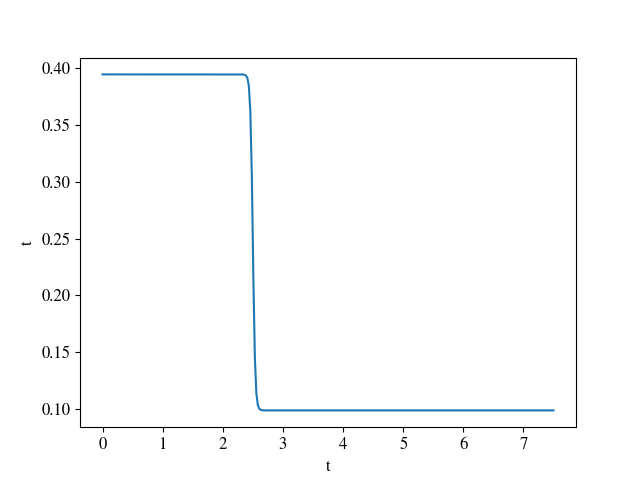

In [14]:
telescope = PotentialT( # We now use a PotentialT object
    unitvecs=[[s, 0], [0, s]],
    resolution=resolution,
    v0 = 0
)

T1 = 10
T2 = 20
w1 = 2*np.pi/T1
w2 = 2*np.pi/T2

t_final = T1/4 + T2/4

telescope.add_shape('trap', (telescope.x**2 + telescope.y**2) / 2) # A normalized harmonic trap is added to the shape context of the telescope 
telescope.step('step', ts = T1/4, sigma = T1/100, vi = w1**2, vf = w2**2) # A time-step function is added, controling the switch between trapping frequencies

telescope.add_term('step * trap')

telescope.plot_timefunction('step', tmin = 0, tmax = t_final, n_t=300)
plt.show()

In [15]:
t_samples = create_parameter('t', np.linspace(t_init, t_final, 99)) # We are going to save 99 time points

bar = SSFM(
    potential = telescope, psi0 = psi0, g = 0
)

psi = bar.solve(
    t_init, t_final, t_samples, parallelize=True, n_cores=6
)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    4.1s remaining:    4.1s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    4.6s finished


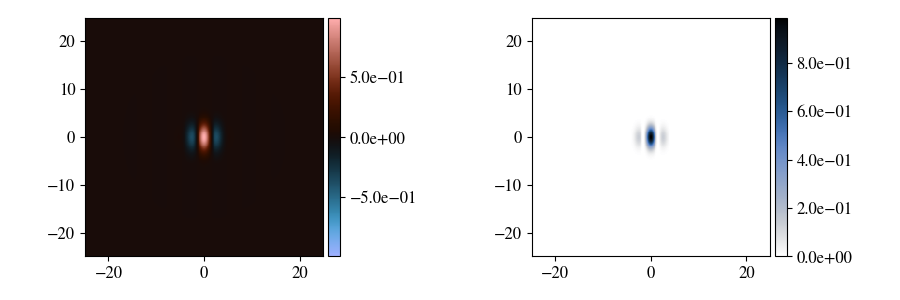

In [16]:
plot_eigenvector(
    [[psi.real, abs(psi)**2]], [[None]*2], [['real', 'amplitude']]
)
plt.show()

The final state $\psi(t = T_1 / 4 + T_2 / 4)$ is indeed a magnified version of the original state, with a further $\pi$-phaseshift added. Numerically-speaking, we have performed a very inefficient interpolation and cropping of our original states. The use of the Gross-Pitaevski equation in this specific case becomes however relevant when considering interacting condensates. As the interactions can lead to aberrations in the magnified image, it is important to be able to caracterize their impact. One can however easily see the issue arising there: As this telescope is meant to magnify the initial condensate, the overall resolution of the simulation grid must be both fine enough to resolve the initial condensate distribution, and large enough to contain the magnified condensate. This issue forces us to use very large grids, slowing significantly the simulations.

## Rescaling the Gross-Piatevskii equation

To solve this issue, we will use the specialized GPE solver contained in the `rSSFM` class, where the "r" stands for "rescaling". This solver implements the resolution of a modified Gross-Pitaevskii equation, where the simulation coordinates are continuously rescaled to keep the condensate at it's initial characteristic size. The theory behind this method can be found in [Bradley et al., 2022](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.106.053316). As the coordinates are constantly rescaled, we also need to recompute continuoulsy the potential over the grid. To do so, we will use the `AnalyticPotential` class, derived from the `PotentialT` class.

### Initial conditions

We are going to try to magnify the mode profile of the ground state of a honeycomb lattice with an additional harmonic trapping potential. To determine this groud state, we are first going to use the 'GroudStateSSFM` class on a regular static potential. The potential reads
$$ V(\mathbf{r}) = V_{\text{harm.}}(\mathbf{r}) - V \sum_{i}^3 \cos ((\mathbf{k}_{i+1} - \mathbf{k}_{i} \cdot \mathbf{r}))$$
with $i=1,2,3$, $k_i$ the 3 lattice-generating laser beams wavevector (with $k_4 = k_1$), $V$ the lattice amplitude and $V_{\text{harm.}}$ a harmonic potential of trapping frequency $\omega_{\text{trap}}$. We suggest looking at the tutorials from the `bloch_schrodinger` package to get more informations on the honeycomb lattice.

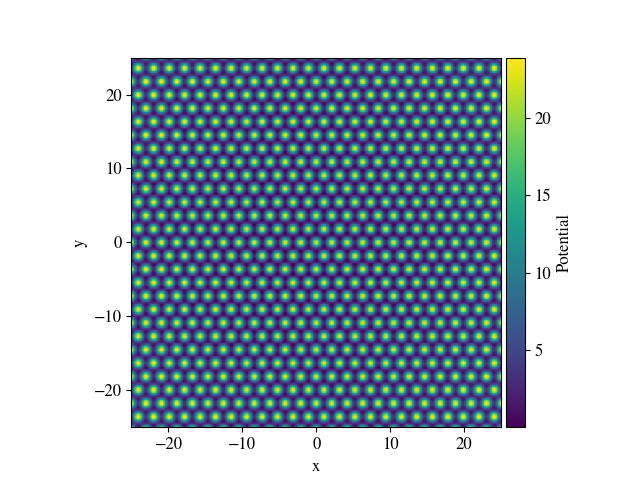

In [17]:
kl = 2 # wavevector amplitude
V = 5 # In units of recoil energy
theta = [2*np.pi/3*i for i in range(3)] # Laser beam angles

w_trap = 0.5e-1  #harmonic confinement frequency

l = 100 # Initial simulation box length
n = 2**9

honey = Potential(
    unitvecs=[[l/2,0], [0,l/2]],
    resolution=(n,n),
    v0 = V*1.5
)

honey.add((honey.x**2+honey.y**2)*w_trap**2/2)

def lattice(x,y):
    pot = 0
    for i in range(3):
        kr = kl*(np.cos(theta[(i+1)%3])-np.cos(theta[i])) * honey.x
        kr += kl*(np.sin(theta[(i+1)%3])-np.sin(theta[i])) * honey.y
        pot += V*np.cos(kr)
    return pot
        
honey.add(lattice(honey.x, honey.y))
    
honey.plot()
plt.show()

Now, let'scompute the ground state for a few values of $g$.

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:  9.2min remaining: 21.4min
[Parallel(n_jobs=10)]: Done   6 out of  10 | elapsed:  9.4min remaining:  6.2min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed: 10.1min finished


Reshaping and storing


100%|██████████| 10/10 [00:00<00:00, 1164.15it/s]


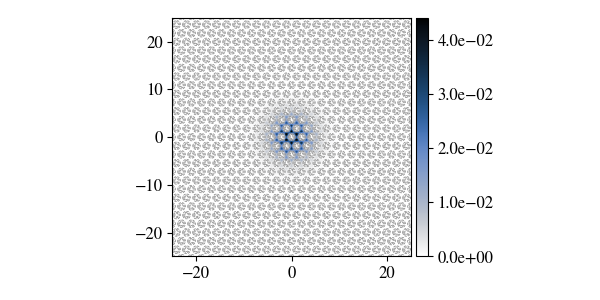

In [18]:
from BECs.groundstate import GroundStateSSFM

g = create_parameter("g", np.arange(10))
# g = 0

HoneyGround = GroundStateSSFM(
    potential = honey, g = g 
)

E, Psi0 = HoneyGround.solve(
    population=1, parallel=True, n_cores=10
)

plot_eigenvector([[abs(Psi0)**2]], [[honey]], [["amplitude"]])
plt.show()

We can see already the effect of the repulsive interactions on the extension of the ground state, but here, we are mostly interested in the interaction-induced aberrations arising when performing a magnification measurement. To do so, we are going to simulate a magnification protocol by a factor 15 and see the result as a function of $g$.

### Analytic potential

We are going to place the initial ground state in our imaging potential, which is a sucession of harmonic traps with different frequencies. The class we are going to use, `AnalyticPotential`, relies on the same principles as `PotentialT`, but is more limited as only analytic functions of time and space can be given as inputs.

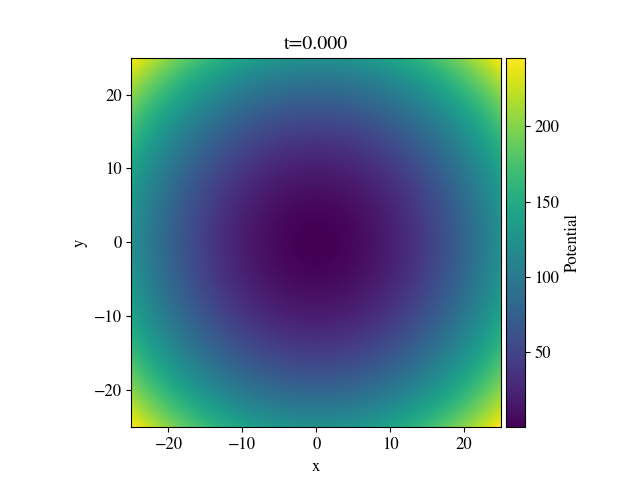

In [19]:
from BECs.potentialT import AnalyticPotential

M = 10 # The magnification factor
T1 = 10 # The first harmonic trap period
T2 = M * T1 # The second harmonic trap period
w1 = 2*np.pi/T1
w2 = 2*np.pi / T2

ti = 0
tf = T1/4 + T2/4

telescope_honey = AnalyticPotential(
    unitvecs = [[l/2,0],[0,l/2]], # These unit vectors define the initial size of the simulation box. They define the rescaled coordinate rho_i at t = 0.
    resolution = (n,n)
)

telescope_honey.step("trap_step", ts = T1/4, sigma = T1/100, vi = w1, vf = w2) # The amplitude step for the harmonic traps of the protocol

telescope_honey.add_function(name = "harmonic_trap", function=lambda t, x, y: x**2+y**2, parameters={}) # A standard harmonic trap shape. The add_function takes as input a function of time and space, plus some eventual parameter dimensions over which to run the simulation
telescope_honey.add_function(name = "lattice", function=lambda t,x,y: lattice(x,y), parameters={})

telescope_honey.add_term("harmonic_trap * (trap_step)**2/2")
telescope_honey.plot(0,tf)
plt.show()

Now we can call the `rSSFM` class to solve the GP equation for our initial conditions.

In [22]:
from BECs.rssfm import rSSFM

solv_honey = rSSFM(
    potential=telescope_honey,
    psi0=Psi0,
    g = g
)

t_samples = create_parameter("t", np.linspace(ti,tf,300))

Psi = solv_honey.solve(
    t_init=ti,
    t_final=tf,
    t_samples=t_samples,
    tol = 1e-7, # speeding up the simulation a bit
    parallelize = True,
    n_cores = 10,
    verbose = False
)
# Takes a few minutes on a standard laptop

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:  5.2min remaining: 12.1min
[Parallel(n_jobs=10)]: Done   6 out of  10 | elapsed:  5.4min remaining:  3.6min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:  6.1min finished


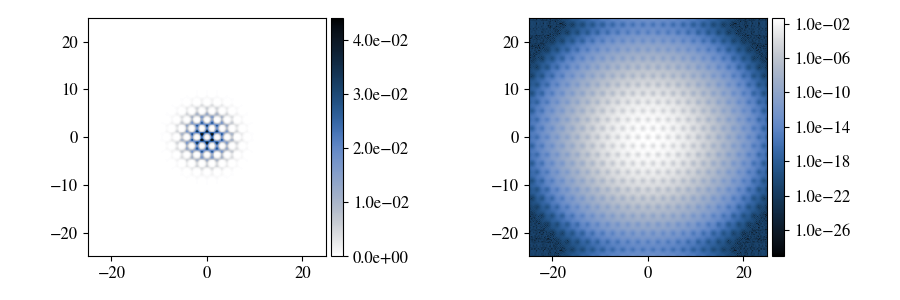

In [23]:
from BECs.plotting import plot_eigenvector_rescaling

# The plot_eigenvector_rescaling function is specificaly designed to handle rescaling grids
plot_eigenvector_rescaling(
    [[abs(Psi)**2]*2], [[None]*2], [["amplitude", "amplitude - log"]], cst_bds=False
)
plt.show()

In [ ]:
from bloch_schrodinger.plotting import plot_cuts
import xarray as xr

Pot = (Psi.x**2 + Psi.y**2) * telescope_honey.create_func("trap_step", {})(Psi.t, 0,0)
PotInt = Pot + Psi.g * abs(Psi)**2

toplot = xr.concat([Pot, PotInt], dim = "ndim")


NotImplementedError: cannot use ``method`` argument if any indexers are slice objects

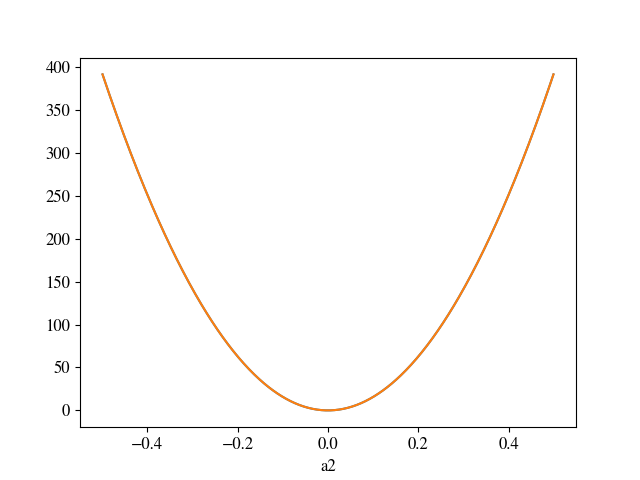

In [30]:

plot_cuts(toplot.sel(t = slice(0,5), a1 = Pot.a1[256]), "a2", ["ndim"])
plt.show()